In [1]:
# Data Integration with Titanic Dataset
import pandas as pd

# 1. Load two datasets
df1 = pd.read_csv("content/titanic_train.csv")
df2 = pd.read_csv("content/titanic_extra.csv")
print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)
print(df1)
print(df2)

# 2. Schema mismatch - rename columns to align
df2.rename(columns={
    "Passenger_ID": "PassengerId",
    "Sex": "Gender",
    "Pclass_level": "Pclass"
}, inplace=True)

# 3. Merge datasets on PassengerId
merged = pd.merge(df1, df2, on="PassengerId", how="outer", suffixes=("_df1", "_df2"))
print("Merged Dataset Shape:", merged.shape)

# 4. Resolve conflicting values
merged["Final_Gender"] = merged.apply(
    lambda row: row["Sex"] if pd.notnull(row["Sex"]) else
row.get("Gender"), axis=1)

merged["Final_Age"] = merged.apply(
    lambda row: row["Age_df1"] if pd.notnull(row.get("Age_df1")) else
row.get("Age_df2"), axis=1)

# 5. Drop redundant columns
cleaned = merged.drop(columns=["Sex", "Gender", "Age_df2"])

# 6. Handle missing values
cleaned["Final_Age"] = cleaned["Final_Age"].fillna(cleaned["Final_Age"].mean())

# 7. Save final integrated dataset
cleaned.to_csv("content/titanic_integrated.csv", index=False)
print("Integrated dataset created: titanic_integrated.csv")

df3=pd.read_csv("content/titanic_integrated.csv")
print("Integrated dataset")
print(df3)

Dataset 1 Shape: (891, 12)
Dataset 2 Shape: (891, 12)
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..             

In [2]:
from sklearn.preprocessing import MinMaxScaler
data = [[-1, 2], [-0.5, 6], [0, 10], [1, 18]]
scaler = MinMaxScaler()
print(scaler.fit(data))
print(scaler.data_max_)
print(scaler.transform(data))

MinMaxScaler()
[ 1. 18.]
[[0.   0.  ]
 [0.25 0.25]
 [0.5  0.5 ]
 [1.   1.  ]]


In [3]:
from numpy import asarray
from sklearn.preprocessing import StandardScaler

data = asarray([[100, 0.001],
 [8, 0.05],
 [50, 0.005],
 [88, 0.07],
 [4, 0.1]])
print(data)

scaler = StandardScaler()

scaled = scaler.fit_transform(data)
print(scaled)

[[1.0e+02 1.0e-03]
 [8.0e+00 5.0e-02]
 [5.0e+01 5.0e-03]
 [8.8e+01 7.0e-02]
 [4.0e+00 1.0e-01]]
[[ 1.26398112 -1.16389967]
 [-1.06174414  0.12639634]
 [ 0.         -1.05856939]
 [ 0.96062565  0.65304778]
 [-1.16286263  1.44302493]]


Original Data (first 5 rows):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


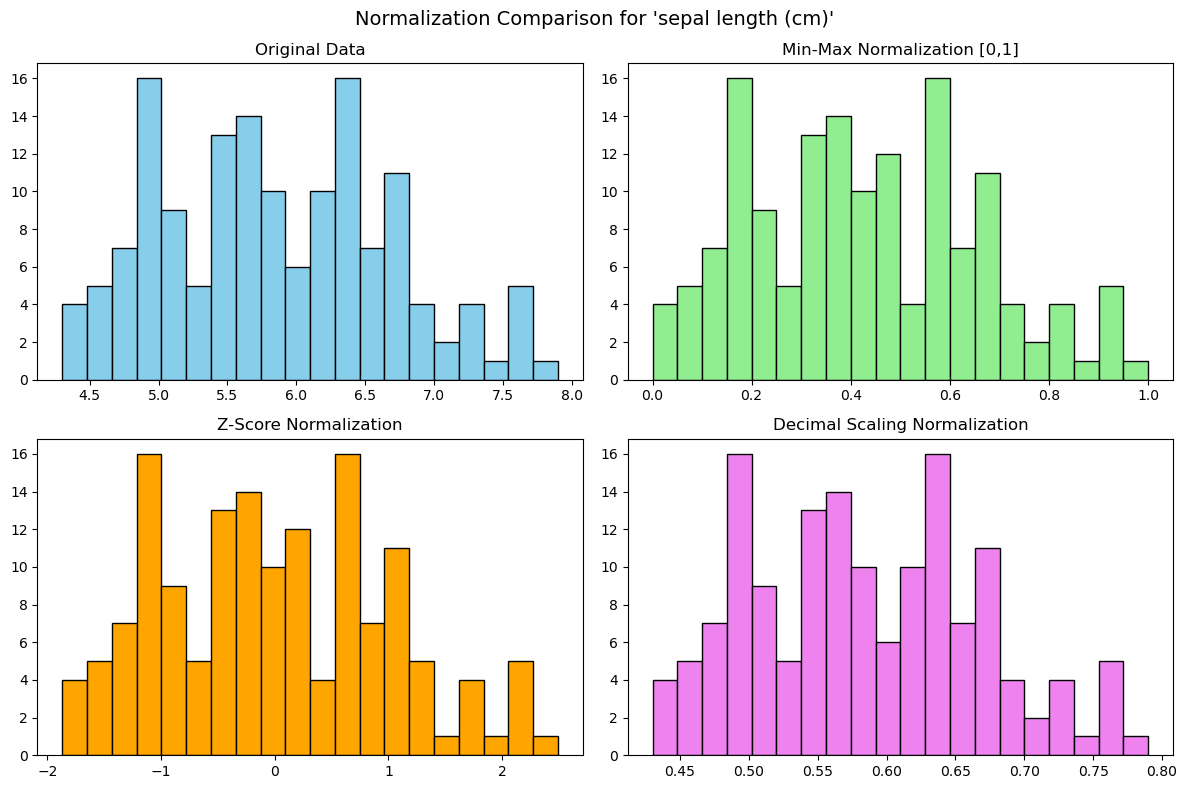

In [4]:
# NORMALIZATION TECHNIQUES WITH PLOTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load Dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print("Original Data (first 5 rows):\n", df.head())

# Min-Max Normalization
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df), columns=df.columns)

# Z-Score Normalization
scaler_zscore = StandardScaler()
df_zscore = pd.DataFrame(scaler_zscore.fit_transform(df), columns=df.columns)

# Decimal Scaling Normalization
def decimal_scaling(series):
    max_val = series.abs().max()
    j = len(str(int(max_val)))
    return series / (10 ** j)
df_decimal = df.apply(decimal_scaling)

# Visualization

feature = "sepal length (cm)"
plt.figure(figsize=(12, 8))

# Original
plt.subplot(2, 2, 1)
plt.hist(df[feature], bins=20, color='skyblue', edgecolor='black')
plt.title("Original Data")

# Min-Max
plt.subplot(2, 2, 2)
plt.hist(df_minmax[feature], bins=20, color='lightgreen',
edgecolor='black')
plt.title("Min-Max Normalization [0,1]")

# Z-Score
plt.subplot(2, 2, 3)
plt.hist(df_zscore[feature], bins=20, color='orange',
edgecolor='black')
plt.title("Z-Score Normalization")

# Decimal Scaling
plt.subplot(2, 2, 4)
plt.hist(df_decimal[feature], bins=20, color='violet', edgecolor='black')
plt.title("Decimal Scaling Normalization")
plt.suptitle(f"Normalization Comparison for '{feature}'", fontsize=14)
plt.tight_layout()
plt.show()
